#SETUP



In [1]:
import os
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow
from base64 import b64decode, b64encode
import cv2
import numpy as np
import PIL
import io
from google.colab import files
import json

HOME = os.getcwd()
print(HOME)

from google.colab import userdata

/kaggle/working


In [2]:
!pip install tqdm --upgrade
!pip install ultralytics roboflow supervision flash-attn torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 4.6 MB/s eta 0:00:00
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.67.1
    Uninstalling tqdm-4.67.1:
      Successfully uninstalled tqdm-4.67.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 60.7 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 1.4 MB/s eta 0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 

In [3]:
!pip install ultralytics

In [4]:
from IPython.display import Image, display
import glob
import random
import yaml
import shutil
import cv2
import torch
import ultralytics
from tqdm.notebook import tqdm
from ultralytics import YOLO

ultralytics.checks()

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6674.4/8062.4 GB disk)


In [5]:


from roboflow import Roboflow
rf = Roboflow(api_key='6uVMLpd9bKgfFJclHKmd')
project = rf.workspace("frysushiws").project("book-cover-detection-14kw2")
version = project.version(8)
dataset = version.download("yolov11")



loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Book-Cover-Detection-8 in yolov11:: 100%|██████████| 11672/11672 [00:01<00:00, 7182.45it/s] 


In [6]:
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!echo -e "test: ../test/images\ntrain: ../train/images\nval: ../valid/images" >> {dataset.location}/data.yaml

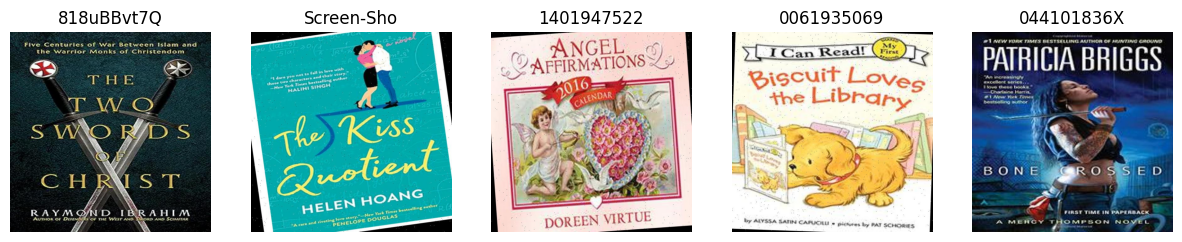

In [7]:
import os
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = "/kaggle/working/Book-Cover-Detection-8/train/images"

image_files = os.listdir(dataset_path)[:5]

plt.figure(figsize=(15, 10))
for i, img_file in enumerate(image_files):
    img_path = os.path.join(dataset_path, img_file)
    img = Image.open(img_path)

    plt.subplot(1, len(image_files), i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_file[:10])
plt.show()

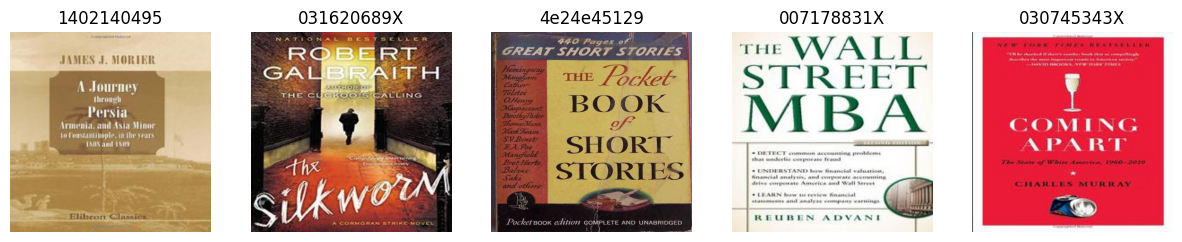

In [8]:
dataset_path = "/kaggle/working/Book-Cover-Detection-8/test/images"

image_files = os.listdir(dataset_path)[:5]

plt.figure(figsize=(15, 10))
for i, img_file in enumerate(image_files):
    img_path = os.path.join(dataset_path, img_file)
    img = Image.open(img_path)

    plt.subplot(1, len(image_files), i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_file[:10])
plt.show()

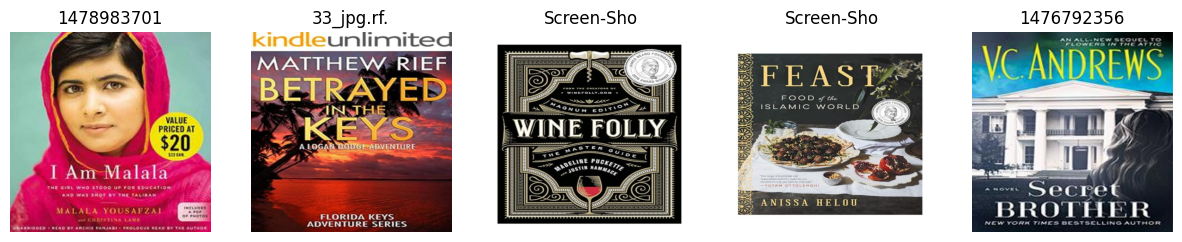

In [9]:
dataset_path = "/kaggle/working/Book-Cover-Detection-8/valid/images"

image_files = os.listdir(dataset_path)[:5]

plt.figure(figsize=(15, 10))
for i, img_file in enumerate(image_files):
    img_path = os.path.join(dataset_path, img_file)
    img = Image.open(img_path)


    plt.subplot(1, len(image_files), i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_file[:10])
plt.show()

#HYPERPARAMETER

In [17]:
!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml \
    epochs=100 imgsz=640 optimizer=RMSProp lr0=0.01 momentum=0.937 weight_decay=0.0005 \
    cos_lr=True warmup_epochs=3 close_mosaic=15 plots=True

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/Book-Cover-Detection-8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=RMSProp, overlap_mask=True, pat

#HASIL

In [22]:
!ls {HOME}/runs/detect/train4/

args.yaml			 results.csv	       val_batch0_labels.jpg
BoxF1_curve.png			 results.png	       val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg      val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg      val_batch1_pred.jpg
BoxR_curve.png			 train_batch27115.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch27116.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch27117.jpg  weights
labels.jpg			 train_batch2.jpg


In [19]:
from IPython.display import Image, display

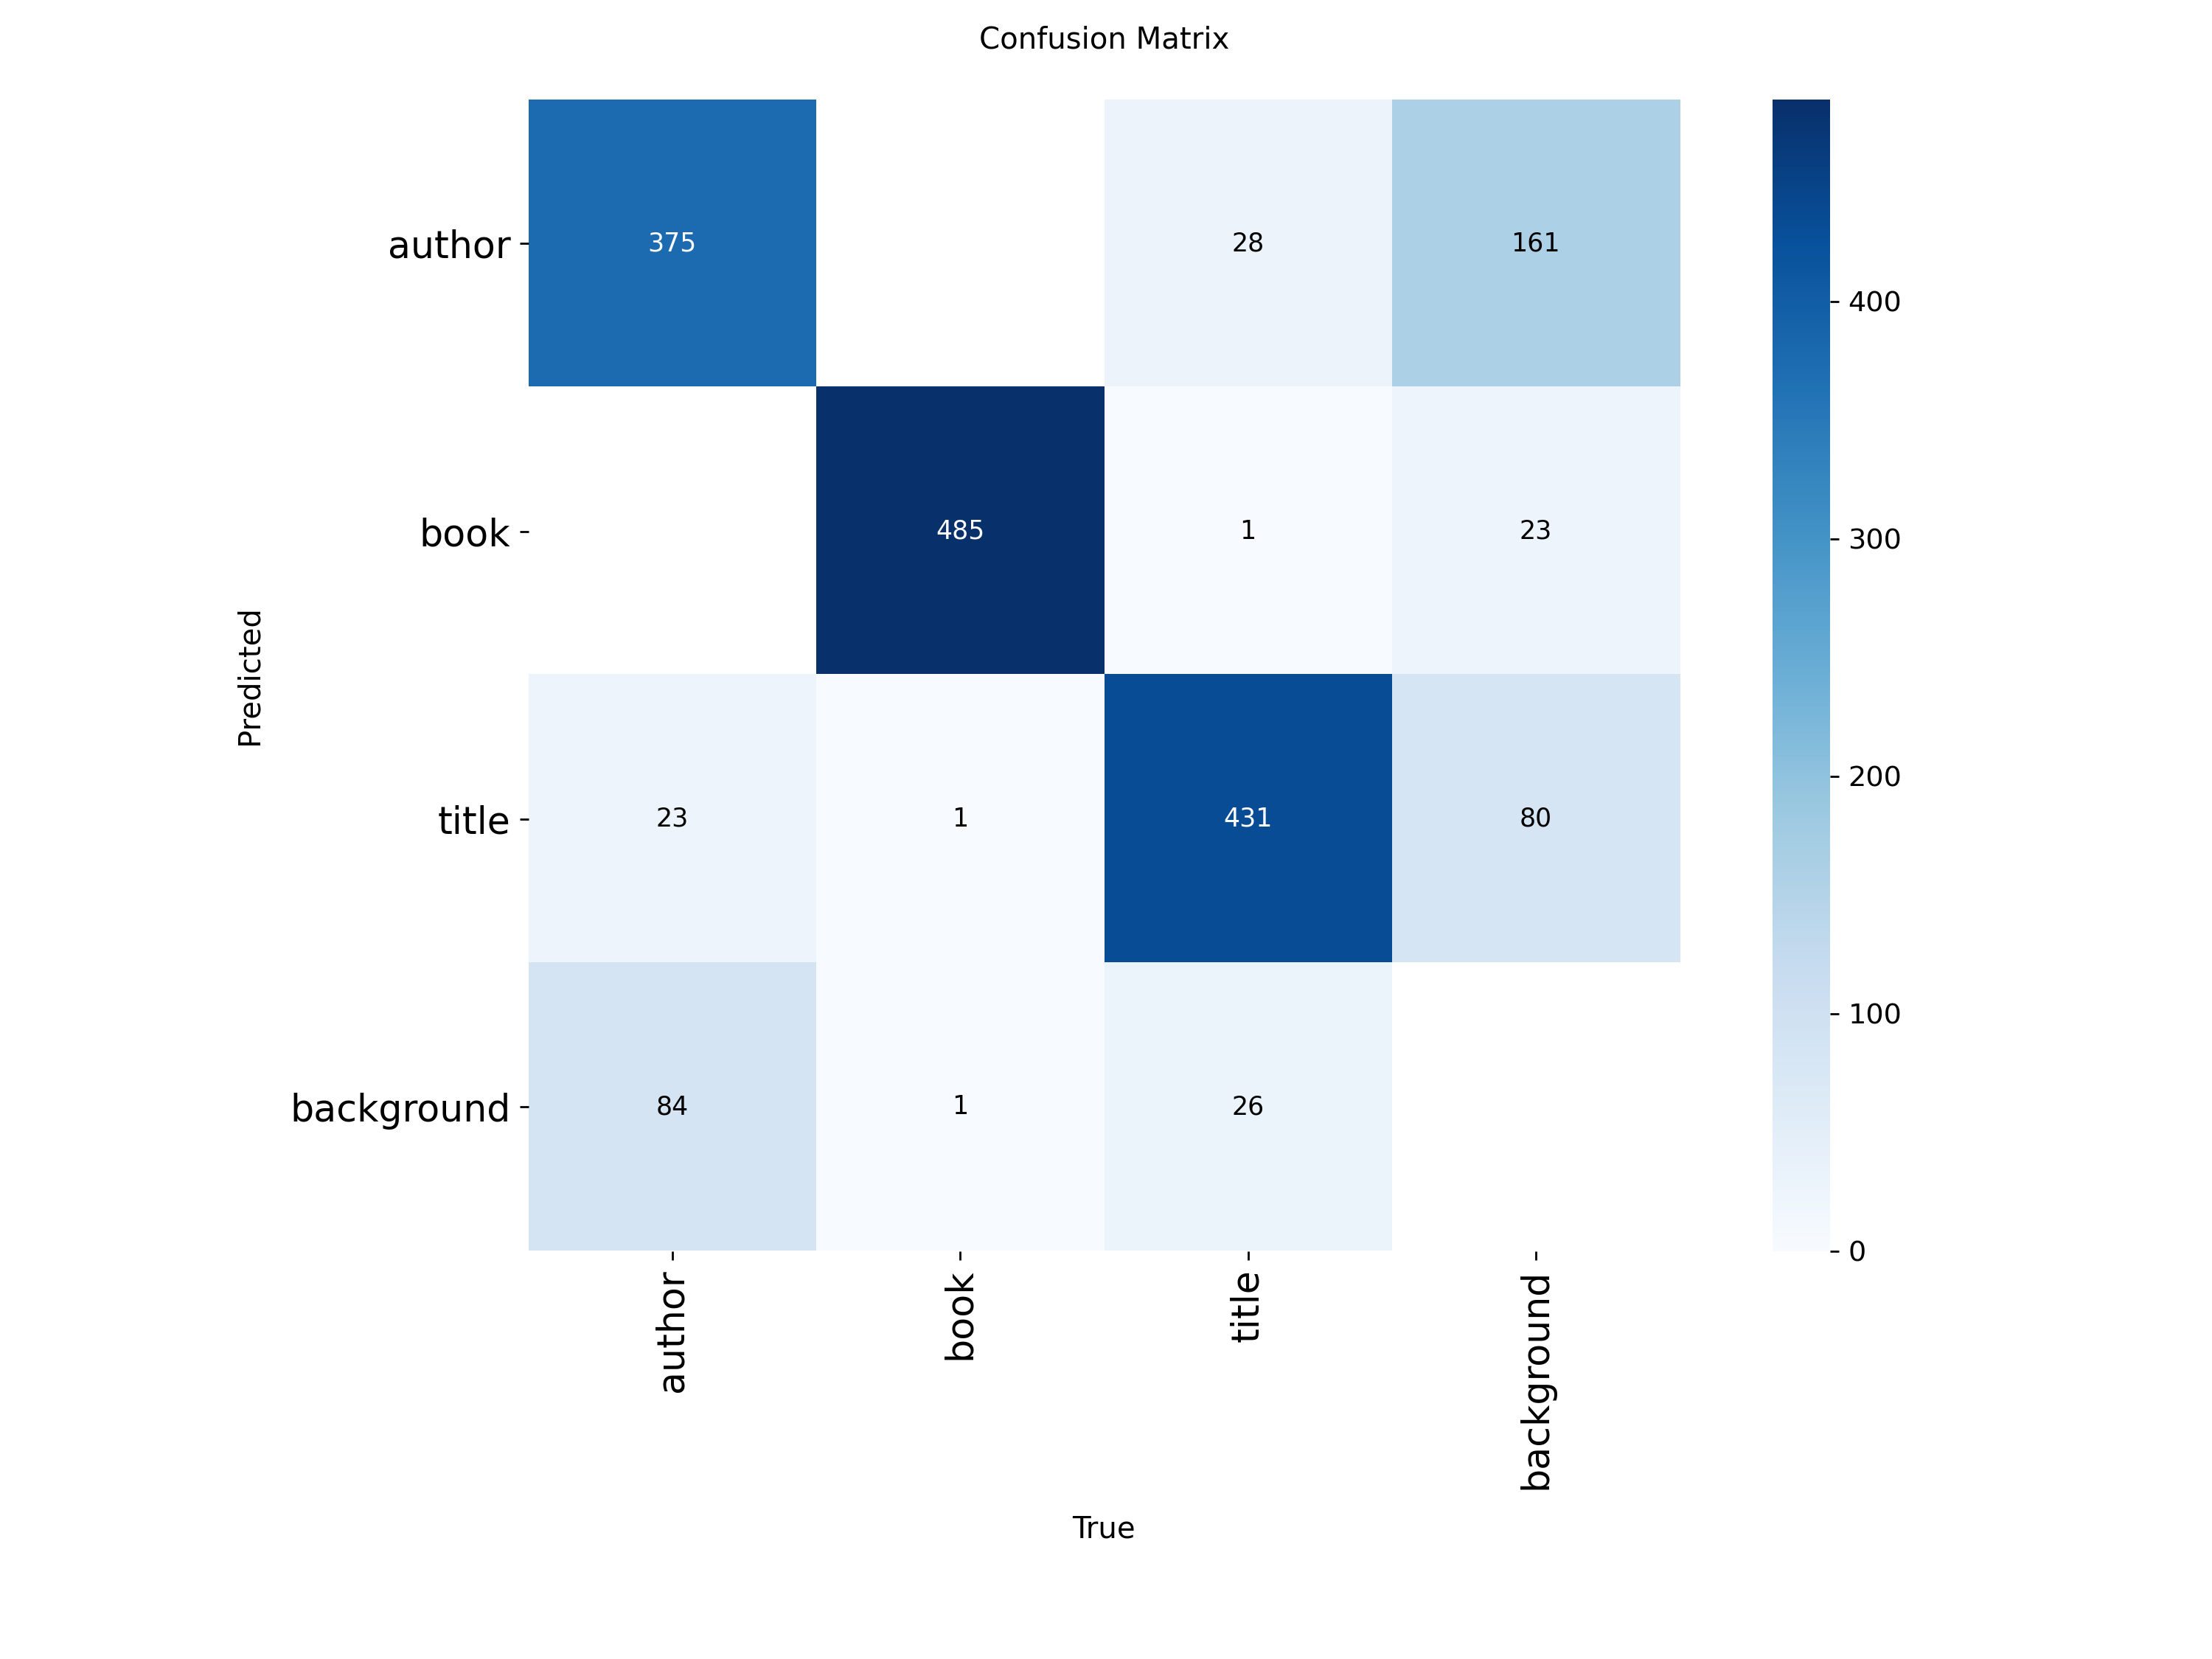

In [23]:
display(Image('/kaggle/working/runs/detect/train4/confusion_matrix.png', width=600))

/kaggle/working


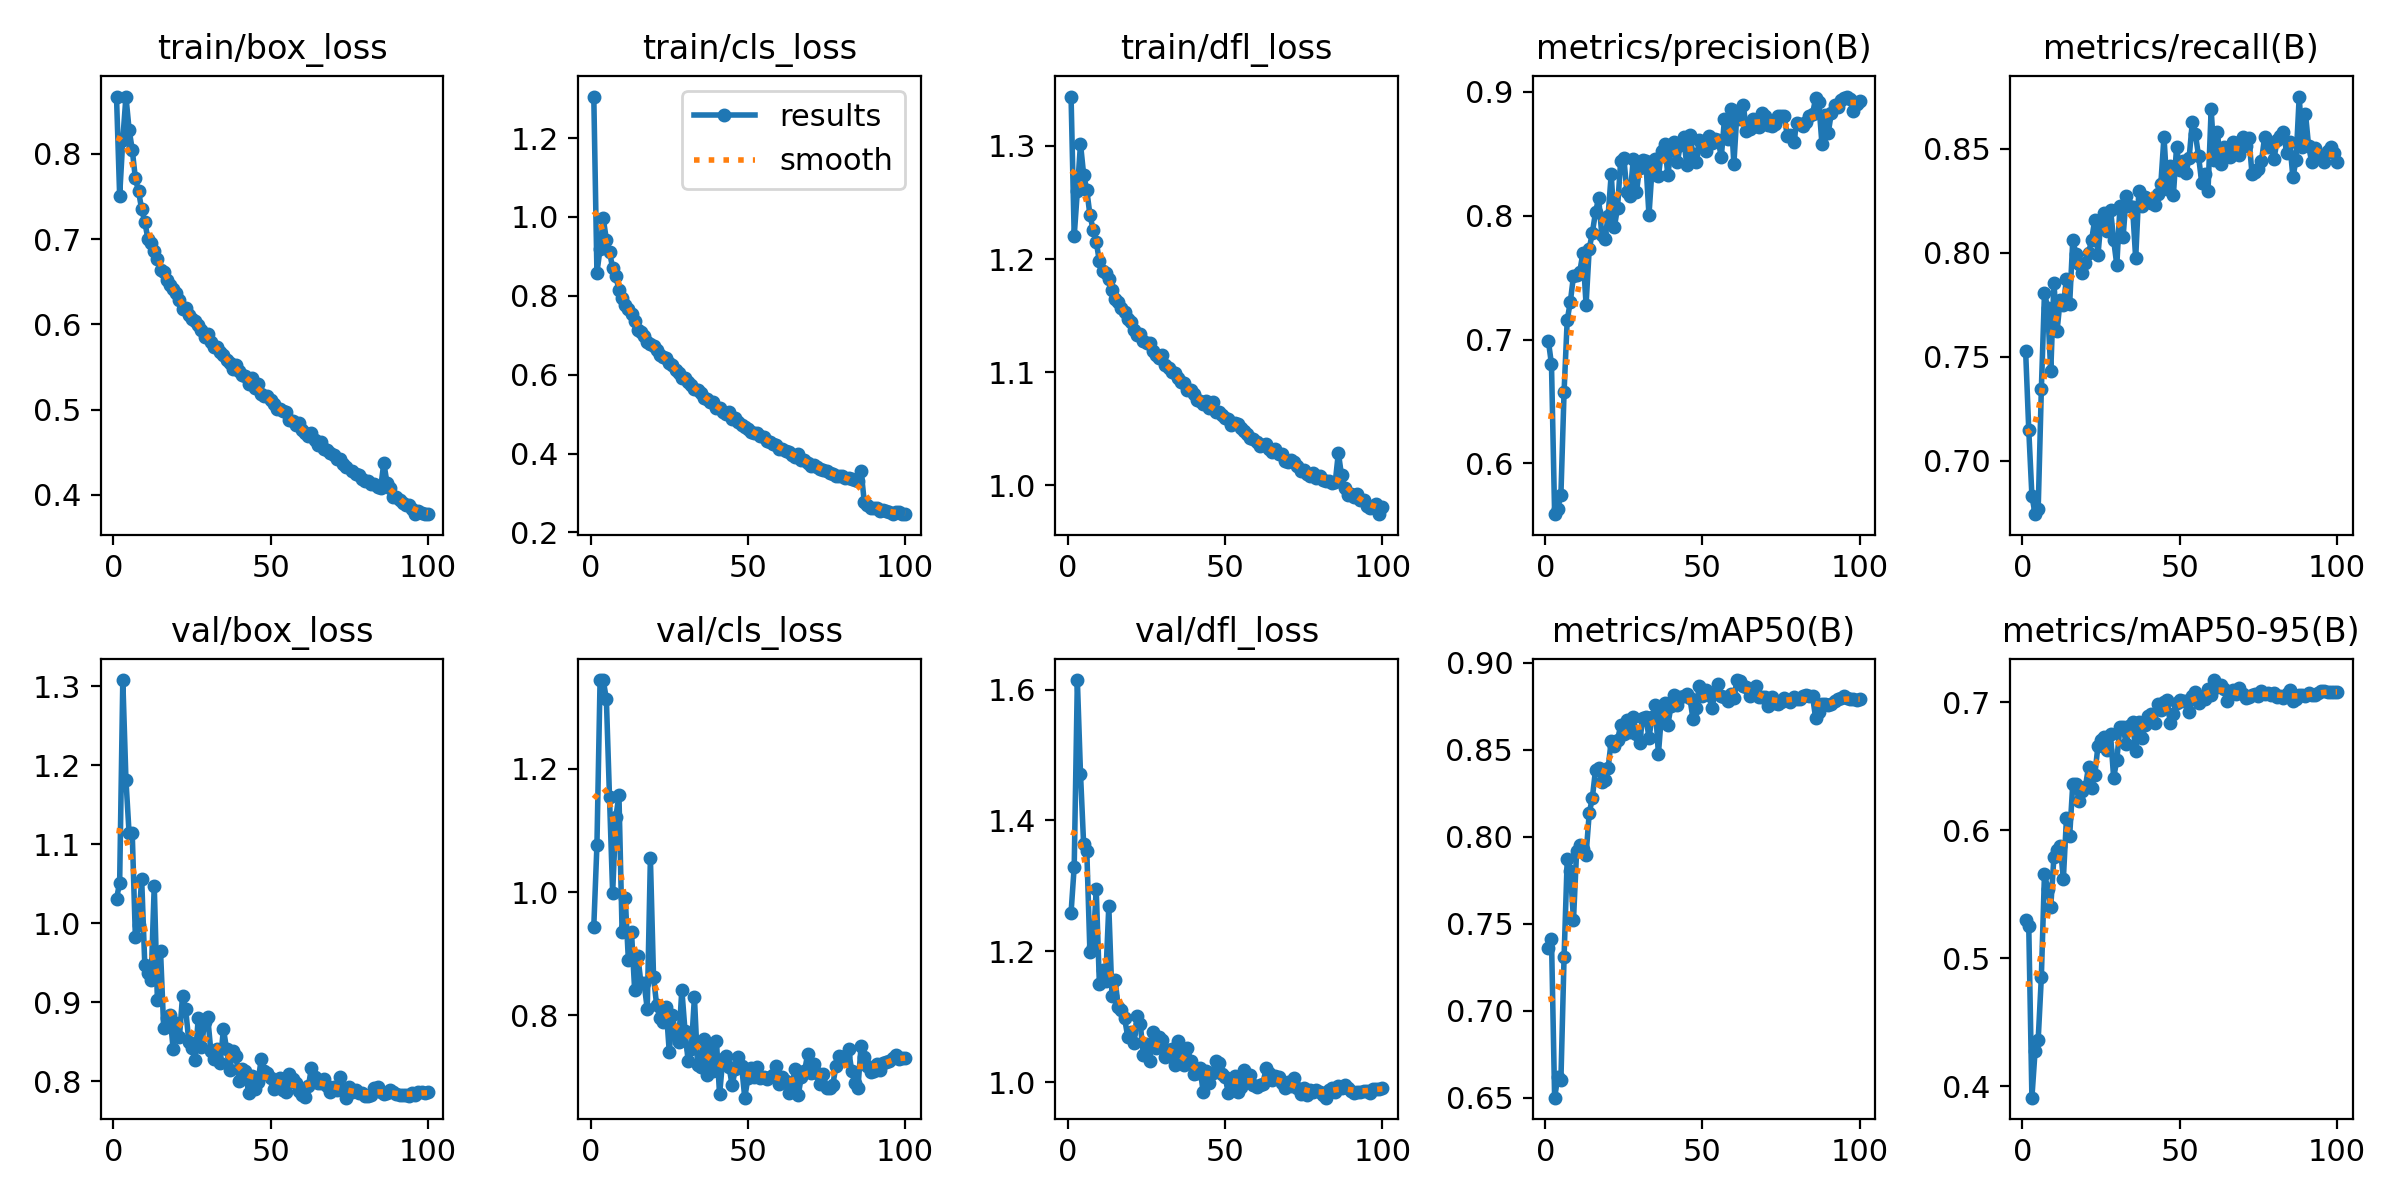

In [24]:
%cd {HOME}
display(Image(filename=f'{HOME}/runs/detect/train4/results.png', width=600))

/kaggle/working


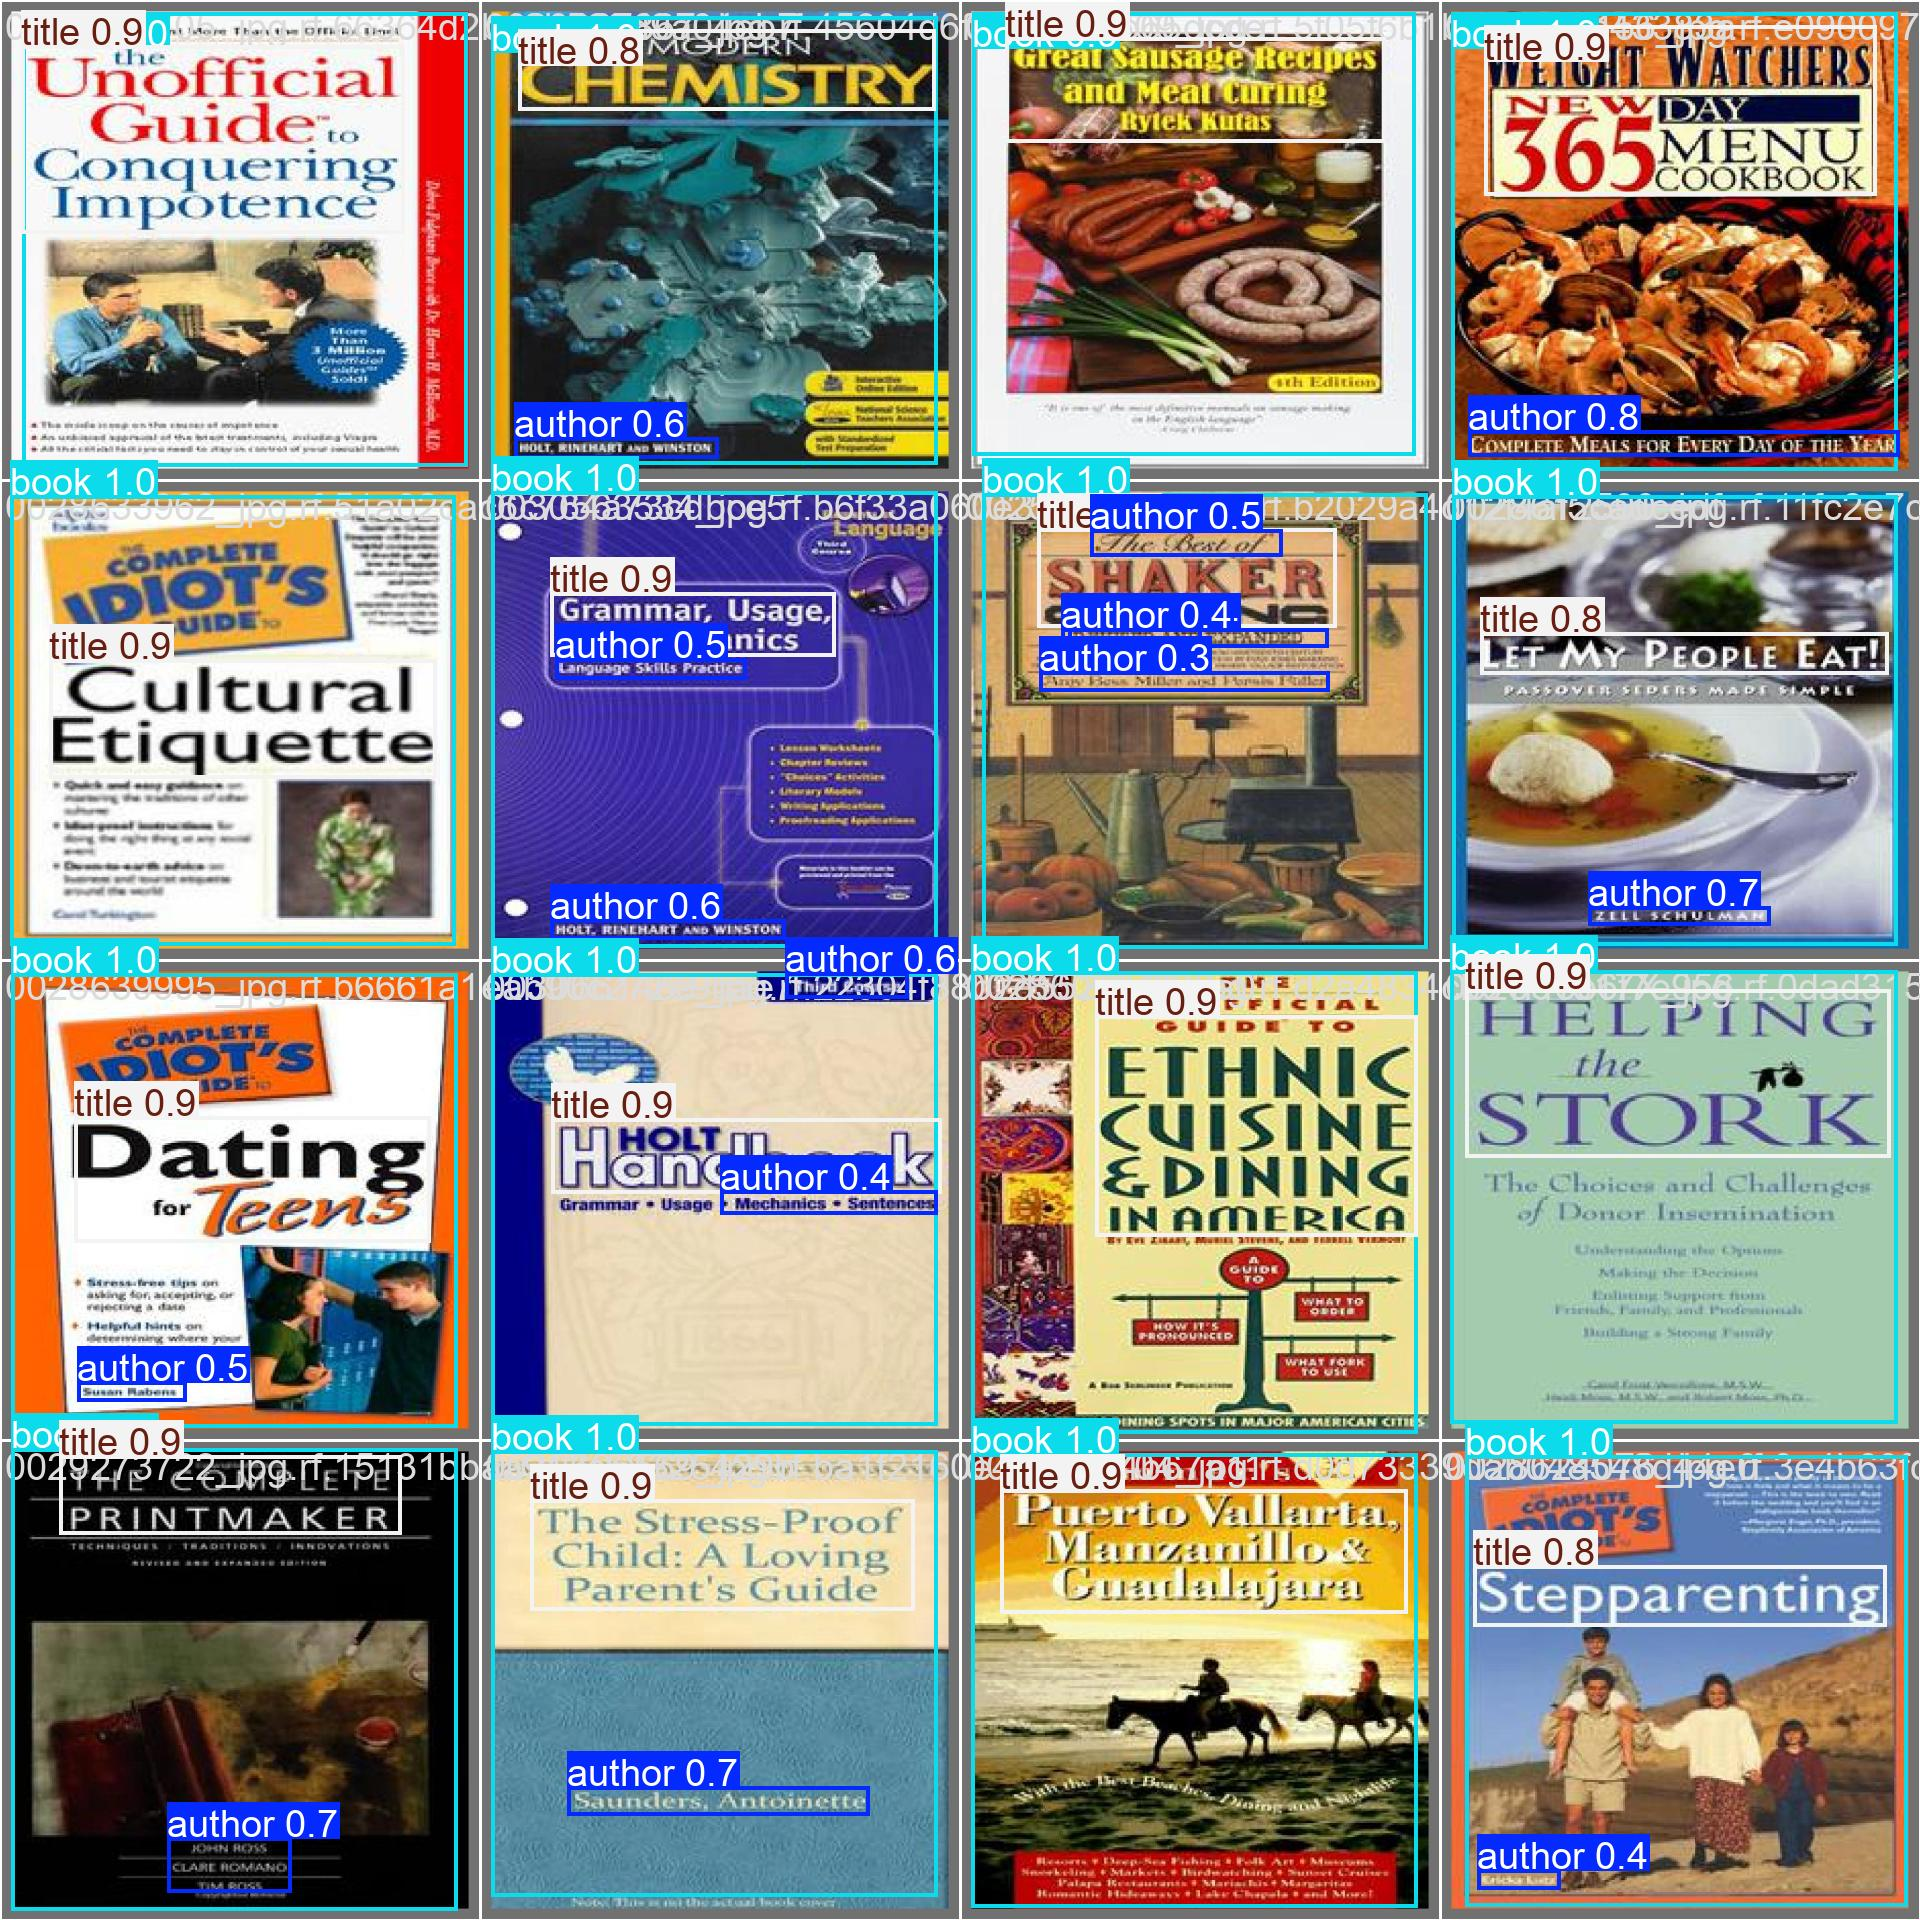

In [25]:
%cd {HOME}
display(Image(filename = f'{HOME}/runs/detect/train4/val_batch1_pred.jpg', width = 600))

In [28]:
model = YOLO('runs/detect/train4/weights/best.pt')
model.export(format='tflite')

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs

PyTorch: starting from 'runs/detect/train4/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (18.3 MB)


E0000 00:00:1772649177.659795      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772649177.782227      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772649178.784170      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772649178.784221      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772649178.784225      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772649178.784228      55 computation_placer.cc:177] computation placer already registered. Please check linka

requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx2tf>=1.26.3,<1.29.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 18 packages in 1.54s
Prepared 7 packages in 2.88s
Installed 7 packages in 15ms
 + ai-edge-litert==2.1.2
 + backports-strenum==1.3.1
 + onnx-graphsurgeon==0.5.8
 + onnx2tf==1.28.8
 + onnxruntime-gpu==1.24.2
 + onnxslim==0.1.86
 + sng4onnx==2.0.1

requirements: AutoUpdate success ✅ 5.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


TensorFlow SavedModel: starting export with tensorflow 2.19.0...

ONNX: starting export with onnx 1.20.1 opset 22...


Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 


ONNX: slimming with onnxslim 0.1.86...
ONNX: export success ✅ 2.6s, saved as 'runs/detect/train4/weights/best.onnx' (36.3 MB)
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /kaggle/working/calibration_image_sample_data_20x128x128x3_float32.npy...: 100% ━━━━━━━━━━━━ 1/1 45.7files/s 0.0s
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...


I0000 00:00:1772649222.684601      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772649222.686622      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1772649227.453047      55 cuda_dnn.cc:529] Loaded cuDNN version 91002


Saved artifact at 'runs/detect/train4/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 7, 8400), dtype=tf.float32, name=None)
Captures:
  134652441706320: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  134652441705168: TensorSpec(shape=(3, 3, 3, 32), dtype=tf.float32, name=None)
  134652441705552: TensorSpec(shape=(32,), dtype=tf.float32, name=None)
  134652440678224: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  134652440678608: TensorSpec(shape=(3, 3, 32, 64), dtype=tf.float32, name=None)
  134652440677840: TensorSpec(shape=(64,), dtype=tf.float32, name=None)
  134652440678800: TensorSpec(shape=(1, 1, 64, 64), dtype=tf.float32, name=None)
  134652440678992: TensorSpec(shape=(64,), dtype=tf.float32, name=None)
  134652440679952: TensorSpec(shape=(4,), dtype=tf.int64, name=None)
  134652440679

I0000 00:00:1772649237.417614      55 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1772649237.417821      55 single_machine.cc:374] Starting new session
I0000 00:00:1772649237.431015      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772649237.432502      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
W0000 00:00:1772649239.437378      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1772649239.437420      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1772649241.222521      55 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1772649241.222

TensorFlow SavedModel: export success ✅ 71.0s, saved as 'runs/detect/train4/weights/best_saved_model' (90.7 MB)

TensorFlow Lite: starting export with tensorflow 2.19.0...
TensorFlow Lite: export success ✅ 0.0s, saved as 'runs/detect/train4/weights/best_saved_model/best_float32.tflite' (36.2 MB)

Export complete (72.0s)
Results saved to /kaggle/working/runs/detect/train4/weights
Predict:         yolo predict task=detect model=runs/detect/train4/weights/best_saved_model/best_float32.tflite imgsz=640 
Validate:        yolo val task=detect model=runs/detect/train4/weights/best_saved_model/best_float32.tflite imgsz=640 data=/kaggle/working/Book-Cover-Detection-8/data.yaml  
Visualize:       https://netron.app


'runs/detect/train4/weights/best_saved_model/best_float32.tflite'